In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import os
import gc
from radioimaging.visibility import ingest
from ska_sdp_func_python.imaging import advise_wide_field
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.interpolate import interp1d
from radioimaging.visibility import partition

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [8, 5]

In [2]:
msname = "../data8/LOW/SGRB_full_averaged.ms/"

[vis], _ = ingest.create_visibility_from_ms(msname, use_weight_spec=True, start_chan=0, end_chan=0, selected_dds=[0])
npix = 512
scale_factor = 1.8
advice = advise_wide_field(vis, guard_band_image=3.0, delA=0.1, facets=1, oversampling_synthesised_beam=4.0)
noise_level = 0.05

cell_size = advice['cellsize'] * scale_factor

In [3]:
uvlambdas = numpy.array(vis.visibility_acc.uvw_lambda[..., 0, 0:2])

uvlambdas = uvlambdas.reshape((int(uvlambdas.shape[0] * uvlambdas.shape[1]), 2))
dist = numpy.zeros(uvlambdas.shape[0])
amplitudes = numpy.abs(vis.vis.data)
for i, uvlambda in enumerate(uvlambdas):
    dist[i] = numpy.sqrt(uvlambda[0]**2 + uvlambda[1]**2)  * cell_size * npix

noise_std = noise_level * numpy.std(amplitudes)
maxamp = numpy.max(amplitudes)

In [12]:
delta = 1
partitions = 15

ecdf = ECDF(dist)
cdf = interp1d(ecdf.x, ecdf.y, bounds_error=False, assume_sorted=True)
icdf = interp1d(ecdf.y, ecdf.x, bounds_error=False, assume_sorted=True)

alpha = partition.dichotomy(cdf, icdf, delta, partitions, tolerance=1e-15)
ells, partition_sizes = partition.get_partitions(cdf, icdf, delta, partitions, alpha)

ells_rounded = [round(x, 2) for x in ells]
print(ells_rounded)
partition_sizes_rounded = partition.get_bin_sizes(cdf, ells_rounded, delta)

[15.71, 29.02, 41.24, 52.88, 56.75, 67.11, 73.59, 85.25, 92.9, 97.23, 121.42, 131.67, 144.33, 146.78]


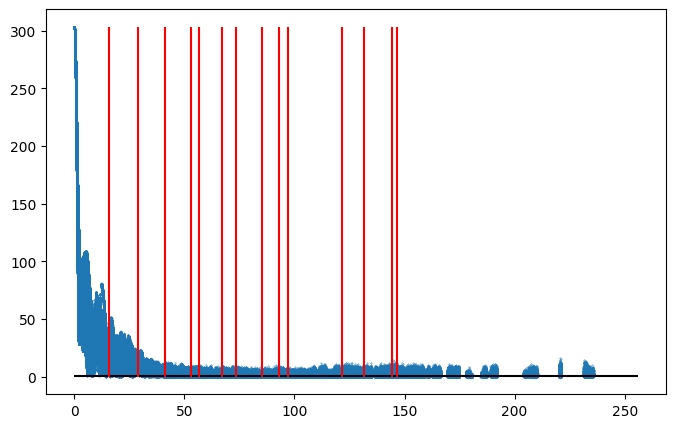

In [11]:
plt.scatter(dist, amplitudes.flatten(), s=0.1)
plt.hlines(noise_std, 0, npix/2, color='black')
plt.vlines(ells_rounded, 0, maxamp, color='red')
plt.show()